# Practical Task 1: PyTorch Regression (MSELoss + Adam)
In this practical exercise, you will build and train a simple regression model using PyTorch. You will learn how to define a neural network, generate synthetic data, use MSELoss, and train the model using the Adam optimizer. 

## Learning Objectives

By the end of this exercise, you will be able to:

    Define a custom PyTorch neural network class using torch.nn.Module.
    Generate synthetic training data for a regression task.
    Configure and train a model using MSELoss and the Adam optimizer.
    Track and interpret training loss across epochs.

## Instructions

### Step 1: Data Generation
    Import torch.
    Generate feature data X with 120 samples and 8 features:
       X = torch.randn(120, 8)
    Create a learnable target using the formula:
       y = X @ w + b + noise, where w (8×1) and b are constants, and noise ~ N(0, 0.5).
    Print X.shape and y.shape to confirm dimensions.
    
### Step 2: Model Definition

    Define a neural network class called RevenueNet that extends torch.nn.Module.
    Include three layers:
       - Input: 8 neurons
       - Hidden: 16 → 8 neurons (ReLU activation)
       - Output: 1 neuron (no activation)
    Print the model architecture after initialization.
    
### Step 3: Model Setup

    Instantiate your RevenueNet model.
    Use torch.nn.MSELoss() as your loss function.
    Use the Adam optimizer with a learning rate of 0.010.
### Step 4: Training Loop

    Train the model for 30 epochs.
    For each epoch:
       Compute predictions with model(X).
       Calculate loss using the MSELoss criterion.
       Zero the gradients, perform backpropagation, and update model weights.

    Print loss after each epoch in the format:
       Epoch 01 | Loss: 0.123456
       
### Step 5: Loss Visualisation
    Use matplotlib to plot the recorded training loss across epochs. Label axes and provide a title. Display the chart with plt.show().
    
### Step 6: Extension Activity (Optional)
    Modify the task to deepen your understanding:
    • Change the number of epochs or learning rate and observe the effect on loss.
    • Add another hidden layer and compare training performance.
    • Increase the noise term to see how it affects learning stability.
    
## Reflection Questions

Answer these questions after completing the exercise:

**1)	What does a decreasing MSE loss tell you about your model’s learning process?**

**2)	What happens if you increase the learning rate to 0.1? Why?**

**3)	How does adding more noise to your target (y) affect training performance?**

**4)	Why is MSELoss appropriate for regression problems instead of BCELoss?**

**5)	In what real-world cybersecurity scenario might regression modelling be used?**

STEP 1: DATA GENERATION
X shape: torch.Size([120, 8])
y shape: torch.Size([120, 1])
Data generation complete!

STEP 2: MODEL DEFINITION
RevenueNet(
  (layer1): Linear(in_features=8, out_features=16, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=8, out_features=1, bias=True)
)

STEP 3: MODEL SETUP
Loss Function: MSELoss()
Optimizer: Adam (learning rate = 0.010)

STEP 4: TRAINING LOOP
Epoch 01 | Loss: 45.652882
Epoch 02 | Loss: 45.180935
Epoch 03 | Loss: 44.639210
Epoch 04 | Loss: 44.031113
Epoch 05 | Loss: 43.343761
Epoch 06 | Loss: 42.568623
Epoch 07 | Loss: 41.697472
Epoch 08 | Loss: 40.722935
Epoch 09 | Loss: 39.616222
Epoch 10 | Loss: 38.394188
Epoch 11 | Loss: 37.044643
Epoch 12 | Loss: 35.562351
Epoch 13 | Loss: 33.957092
Epoch 14 | Loss: 32.229393
Epoch 15 | Loss: 30.396339
Epoch 16 | Loss: 28.478392
Epoch 17 | Loss: 26.493874
Epoch 18 | Loss: 24.475245
Epoch 19 | Loss: 22.490223
Epoch 2

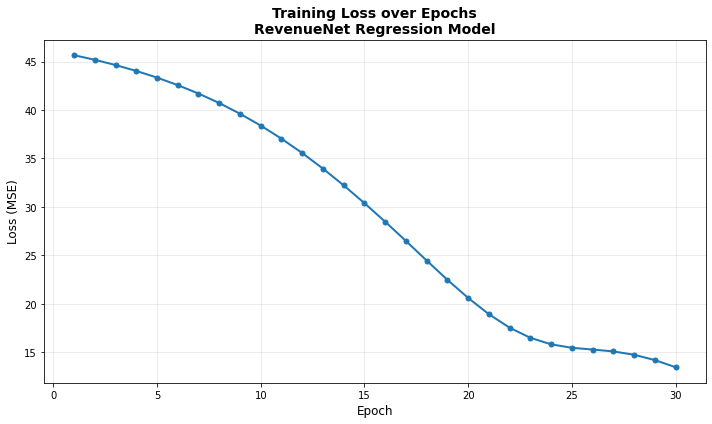

Visualization complete!

MODEL EVALUATION
Final MSE Loss: 12.620400
Mean Absolute Error: 2.669307
Loss Reduction: 70.50%

Sample Predictions (first 5 samples):
Predicted       Actual          Difference
---------------------------------------------
-1.3596         8.0609          9.4204
-3.9222         -4.6064         0.6842
-1.4448         2.8998          4.3446
-1.5252         1.9611          3.4864
-12.3872        -11.0378        1.3494


In [1]:
# ============================================
# PyTorch Regression Task - Complete Solution
# MSELoss + Adam Optimizer
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Set seed for reproducibility
torch.manual_seed(42)

# ============================================
# STEP 1: DATA GENERATION
# ============================================
print("=" * 50)
print("STEP 1: DATA GENERATION")
print("=" * 50)

# Generate feature data X with 120 samples and 8 features
X = torch.randn(120, 8)

# Create learnable target: y = X @ w + b + noise
w = torch.randn(8, 1) * 2  # Random weights
b = torch.randn(1) * 5      # Random bias
noise = torch.randn(120, 1) * 0.5  # Noise ~ N(0, 0.5)

y = X @ w + b + noise

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Data generation complete!\n")

# ============================================
# STEP 2: MODEL DEFINITION
# ============================================
print("=" * 50)
print("STEP 2: MODEL DEFINITION")
print("=" * 50)

class RevenueNet(nn.Module):
    def __init__(self):
        super(RevenueNet, self).__init__()
        # Input layer: 8 features
        self.layer1 = nn.Linear(8, 16)
        self.relu1 = nn.ReLU()
        
        # Hidden layer: 16 -> 8
        self.layer2 = nn.Linear(16, 8)
        self.relu2 = nn.ReLU()
        
        # Output layer: 8 -> 1
        self.layer3 = nn.Linear(8, 1)
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.relu1(x)
        x = self.layer2(x)
        x = self.relu2(x)
        x = self.layer3(x)
        return x

# Instantiate and print model
model = RevenueNet()
print(model)
print()

# ============================================
# STEP 3: MODEL SETUP
# ============================================
print("=" * 50)
print("STEP 3: MODEL SETUP")
print("=" * 50)

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.010)

print("Loss Function: MSELoss()")
print("Optimizer: Adam (learning rate = 0.010)")
print()

# ============================================
# STEP 4: TRAINING LOOP
# ============================================
print("=" * 50)
print("STEP 4: TRAINING LOOP")
print("=" * 50)

# Storage for losses
losses = []

# Train for 30 epochs
num_epochs = 30

for epoch in range(num_epochs):
    # Forward pass: compute predictions
    predictions = model(X)
    
    # Compute loss
    loss = criterion(predictions, y)
    
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    
    # Backward pass: compute gradients
    loss.backward()
    
    # Update weights
    optimizer.step()
    
    # Store loss
    losses.append(loss.item())
    
    # Print loss
    print(f"Epoch {epoch + 1:02d} | Loss: {loss.item():.6f}")

print("\nTraining complete!")
print(f"Final Loss: {losses[-1]:.6f}")
print()

# ============================================
# STEP 5: LOSS VISUALIZATION
# ============================================
print("=" * 50)
print("STEP 5: LOSS VISUALIZATION")
print("=" * 50)

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), losses, marker='o', linewidth=2, markersize=5)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training Loss over Epochs\nRevenueNet Regression Model', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualization complete!")
print()

# ============================================
# MODEL EVALUATION
# ============================================
print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

with torch.no_grad():
    final_predictions = model(X)
    final_loss = criterion(final_predictions, y)
    
    # Calculate average absolute error
    mae = torch.mean(torch.abs(final_predictions - y))
    
    print(f"Final MSE Loss: {final_loss.item():.6f}")
    print(f"Mean Absolute Error: {mae.item():.6f}")
    print(f"Loss Reduction: {((losses[0] - losses[-1]) / losses[0] * 100):.2f}%")

# Sample predictions
print("\nSample Predictions (first 5 samples):")
print(f"{'Predicted':<15} {'Actual':<15} {'Difference'}")
print("-" * 45)
for i in range(5):
    pred = final_predictions[i].item()
    actual = y[i].item()
    diff = abs(pred - actual)
    print(f"{pred:<15.4f} {actual:<15.4f} {diff:.4f}")

### Step 6: Extension Activities (Run These Separately)
Extension 1: Different Learning Rates

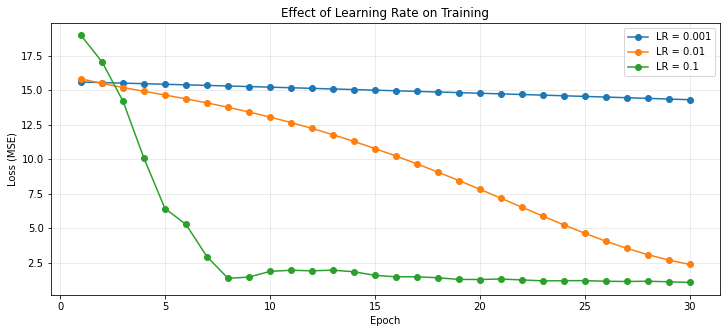

In [3]:
# Compare different learning rates
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(12, 5))

for lr in learning_rates:
    # Reset model
    model_test = RevenueNet()
    optimizer_test = optim.Adam(model_test.parameters(), lr=lr)
    criterion_test = nn.MSELoss()
    
    losses_test = []
    
    for epoch in range(30):
        predictions = model_test(X)
        loss = criterion_test(predictions, y)
        
        optimizer_test.zero_grad()
        loss.backward()
        optimizer_test.step()
        
        losses_test.append(loss.item())
    
    plt.plot(range(1, 31), losses_test, marker='o', label=f'LR = {lr}')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Effect of Learning Rate on Training')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Extension 2: Add Another Hidden Layer

In [4]:
class DeepRevenueNet(nn.Module):
    def __init__(self):
        super(DeepRevenueNet, self).__init__()
        self.layer1 = nn.Linear(8, 16)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(16, 16)  # Additional layer
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(16, 8)
        self.relu3 = nn.ReLU()
        self.layer4 = nn.Linear(8, 1)
    
    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))  # Additional layer
        x = self.relu3(self.layer3(x))
        x = self.layer4(x)
        return x

# Train and compare
deep_model = DeepRevenueNet()
print(deep_model)

DeepRevenueNet(
  (layer1): Linear(in_features=8, out_features=16, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=16, out_features=16, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=16, out_features=8, bias=True)
  (relu3): ReLU()
  (layer4): Linear(in_features=8, out_features=1, bias=True)
)


### Extension 3: Increase Noise

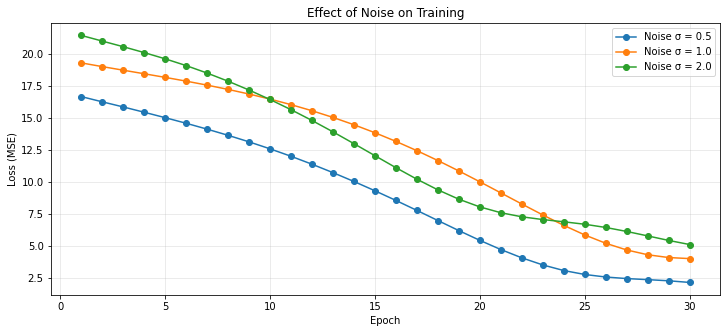

In [6]:
# Generate data with different noise levels
noise_levels = [0.5, 1.0, 2.0]

plt.figure(figsize=(12, 5))

for noise_std in noise_levels:
    # Generate new data with more noise
    noise = torch.randn(120, 1) * noise_std
    y_noisy = X @ w + b + noise
    
    # Train model
    model_noise = RevenueNet()
    optimizer_noise = optim.Adam(model_noise.parameters(), lr=0.01)
    criterion_noise = nn.MSELoss()
    
    losses_noise = []
    
    for epoch in range(30):
        predictions = model_noise(X)
        loss = criterion_noise(predictions, y_noisy)
        
        optimizer_noise.zero_grad()
        loss.backward()
        optimizer_noise.step()
        
        losses_noise.append(loss.item())
    
    plt.plot(range(1, 31), losses_noise, marker='o', label=f'Noise σ = {noise_std}')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Effect of Noise on Training')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 1. What does a decreasing MSE loss tell you about your model's learning process?
A decreasing MSE loss indicates that the model is successfully learning the underlying relationship between input features and target values. The model's predictions are getting progressively closer to the actual values, meaning the neural network is adjusting its weights effectively through backpropagation to minimize the squared differences between predictions and ground truth.
## 2. What happens if you increase the learning rate to 0.1? Why?
Increasing the learning rate to 0.1 typically causes:

    Unstable training: Loss may oscillate wildly or increase
    Overshooting: The optimizer takes steps too large, jumping over the optimal minimum
    Potential divergence: The model may fail to converge entirely, with loss exploding to infinity

This happens because the learning rate controls the step size in gradient descent. Too large a step can overshoot the optimal point in the loss landscape.
## 3. How does adding more noise to your target (y) affect training performance?
Increasing noise in the target variable causes:

    Higher final loss: The model cannot fit the noise, only the true underlying pattern
    Slower convergence: Takes more epochs to learn the signal from the noise
    Less stable training: Loss curve becomes more erratic
    Lower model accuracy: The best possible performance is limited by the noise level

## 4. Why is MSELoss appropriate for regression problems instead of BCELoss?
MSELoss is designed for regression because:

    It measures continuous distance between predicted and actual values
    Penalizes large errors more heavily (squared term)
    Works with unbounded continuous outputs

BCELoss is for binary classification because:

It measures probability distributions (values between 0 and 1)

Designed for yes/no, true/false predictions

Would give nonsensical results for continuous values like 15.7 or -3.2

## 5. In what real-world cybersecurity scenario might regression modeling be used?
Several cybersecurity applications:

    Network Traffic Prediction: Forecasting bandwidth usage to detect DDoS attacks
    Attack Severity Scoring: Predicting CVSS scores from vulnerability features
    Intrusion Detection Timing: Estimating time-to-compromise based on system configurations
    Resource Utilization: Predicting CPU/memory usage for anomaly detection
    Threat Risk Assessment: Calculating continuous risk scores for security events
    Password Strength Estimation: Predicting crack time based on password characteristics

X shape: torch.Size([120, 8])
y shape: torch.Size([120, 1])

Model Architecture:
 RevenueNet(
  (layers): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)
Epoch 01 | Loss: 17.017054
Epoch 02 | Loss: 16.638332
Epoch 03 | Loss: 16.248749
Epoch 04 | Loss: 15.852692
Epoch 05 | Loss: 15.435885
Epoch 06 | Loss: 15.000300
Epoch 07 | Loss: 14.532960
Epoch 08 | Loss: 14.031085
Epoch 09 | Loss: 13.486239
Epoch 10 | Loss: 12.891541
Epoch 11 | Loss: 12.240780
Epoch 12 | Loss: 11.537084
Epoch 13 | Loss: 10.775979
Epoch 14 | Loss: 9.964945
Epoch 15 | Loss: 9.109327
Epoch 16 | Loss: 8.230111
Epoch 17 | Loss: 7.346613
Epoch 18 | Loss: 6.487339
Epoch 19 | Loss: 5.685731
Epoch 20 | Loss: 4.975835
Epoch 21 | Loss: 4.392206
Epoch 22 | Loss: 3.957856
Epoch 23 | Loss: 3.675674
Epoch 24 | Loss: 3.525702
Epoch 25 | Loss: 3.463195
Epoch

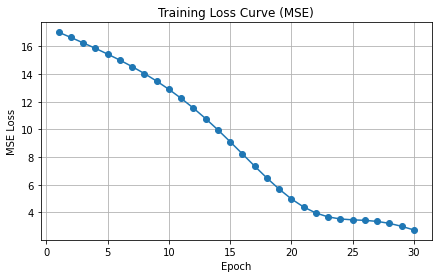

In [2]:
# Step 1: Data Generation
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)

# Generate features (120 samples × 8 features)
X = torch.randn(120, 8)

# True weights and bias
w = torch.randn(8, 1)   # 8×1
b = 3.0

# Generate target with noise ~ N(0, 0.5)
noise = torch.randn(120, 1) * 0.5
y = X @ w + b + noise

# Check dimensions
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


# Step 2: Model Definition
class RevenueNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(8, 16),   # Input → Hidden1
            nn.ReLU(),
            nn.Linear(16, 8),   # Hidden1 → Hidden2
            nn.ReLU(),
            nn.Linear(8, 1)     # Hidden2 → Output
        )
    
    def forward(self, x):
        return self.layers(x)

# Initialize model
model = RevenueNet()
print("\nModel Architecture:\n", model)


# Step 3: Model Setup
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.010)


# Step 4: Training Loop
epochs = 30
losses = []

for epoch in range(epochs):
    # Forward pass
    y_pred = model(X)
    
    # Compute loss
    loss = loss_fn(y_pred, y)
    losses.append(loss.item())
    
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Print loss every epoch
    print(f"Epoch {epoch+1:02d} | Loss: {loss.item():.6f}")


# Step 5: Loss Visualization
plt.figure(figsize=(7,4))
plt.plot(range(1, epochs+1), losses, marker='o')
plt.title("Training Loss Curve (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

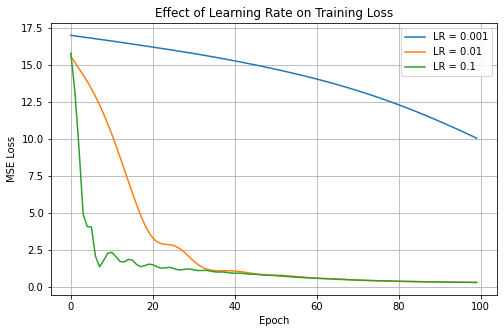

In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Reuse same dataset
X = torch.randn(120, 8)
w = torch.randn(8, 1)
b = 3.0
noise = torch.randn(120, 1) * 0.5
y = X @ w + b + noise

# Define model (same architecture)
class RevenueNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        return self.layers(x)


def train_model(lr, epochs):
    model = RevenueNet()
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(epochs):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return losses


# Train with different setups
loss_lr_low = train_model(lr=0.001, epochs=100)
loss_lr_normal = train_model(lr=0.01, epochs=100)
loss_lr_high = train_model(lr=0.1, epochs=100)

# Plot comparison
plt.figure(figsize=(8,5))
plt.plot(loss_lr_low, label='LR = 0.001')
plt.plot(loss_lr_normal, label='LR = 0.01')
plt.plot(loss_lr_high, label='LR = 0.1')
plt.title("Effect of Learning Rate on Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

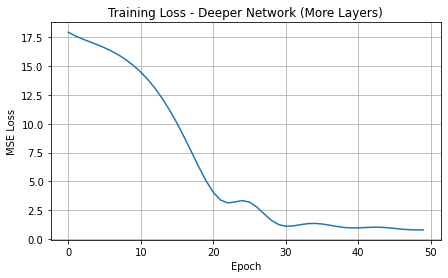

In [8]:
class DeepRevenueNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(8, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        return self.layers(x)

model = DeepRevenueNet()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 50
losses = []

for epoch in range(epochs):
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(7,4))
plt.plot(losses)
plt.title("Training Loss - Deeper Network (More Layers)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

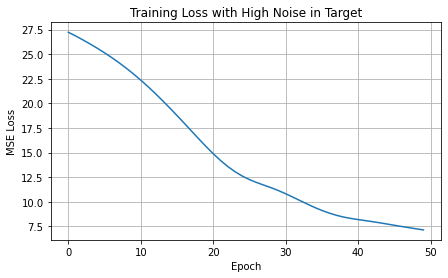

In [9]:
noise = torch.randn(120, 1) * 3.0   # instead of 0.5
y_noisy = X @ w + b + noise

model = RevenueNet()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 50
losses = []

for epoch in range(epochs):
    y_pred = model(X)
    loss = loss_fn(y_pred, y_noisy)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(7,4))
plt.plot(losses)
plt.title("Training Loss with High Noise in Target")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()